# 🇰🇪 Kenya Interest Rates & Inflation — A 65-Year Data Science Analysis
---
**Scope:** Annual data spanning 1960–2024 (inflation) and 1971–2023 (interest rates)  
**Objectives:**
1. Independently analyse Kenya's interest rate history (trends, distribution, volatility, regimes, stationarity)
2. Independently analyse Kenya's inflation history with the same rigour
3. Explore the correlation and causal relationship between the two series

> *All cells are self-contained and reproducible. Run top-to-bottom.*


## 0. Environment Setup & Data Loading

In [1]:
# ── Standard imports ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
plt.style.use('seaborn-darkgrid')
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, grangercausalitytests, coint
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

# ── Global plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
KENYA_GREEN  = '#006600'
KENYA_RED    = '#BB0000'
KENYA_GOLD   = '#D4AF37'
NEUTRAL_BLUE = '#2166AC'


In [2]:
# ── Load datasets ─────────────────────────────────────────────────────────────
ir_raw  = pd.read_csv('kenya_interest_rates.csv')   # columns: year, interest_rate
inf_raw = pd.read_csv('kenya_inflation_data.csv')    # columns: year, inflation

# ── Basic cleaning ────────────────────────────────────────────────────────────
ir_raw  = ir_raw.dropna().sort_values('year').reset_index(drop=True)
inf_raw = inf_raw.dropna().sort_values('year').reset_index(drop=True)

# ── Quick sanity check ────────────────────────────────────────────────────────
print("Interest Rate dataset:")
print(f"  Rows : {len(ir_raw)}  |  Years: {ir_raw.year.min()} – {ir_raw.year.max()}")
print()
print("Inflation dataset:")
print(f"  Rows : {len(inf_raw)}  |  Years: {inf_raw.year.min()} – {inf_raw.year.max()}")
print()
print("── Interest Rate head ──")
display(ir_raw.head())
print("── Inflation head ──")
display(inf_raw.head())


Interest Rate dataset:
  Rows : 53  |  Years: 1971 – 2023

Inflation dataset:
  Rows : 65  |  Years: 1960 – 2024

── Interest Rate head ──


,year,interest_rate
0,1971,20.07
1,1972,7.70
2,1973,-1.09
3,1974,-5.64
4,1975,-1.64


── Inflation head ──


,year,inflation
0,1960,1.243781
1,1961,2.457002
2,1962,3.117506
3,1963,0.697674
4,1964,-0.099305


---
## 1. Interest Rate Analysis
### 1.1 Descriptive Statistics


In [3]:
ir = ir_raw.copy()

desc = ir['interest_rate'].describe(percentiles=[.10,.25,.50,.75,.90])
skew = ir['interest_rate'].skew()
kurt = ir['interest_rate'].kurtosis()

print("═" * 45)
print("  DESCRIPTIVE STATISTICS — Interest Rate")
print("═" * 45)
for stat, val in desc.items():
    print(f"  {stat:<12}: {val:>10.3f} %")
print(f"  {'Skewness':<12}: {skew:>10.3f}")
print(f"  {'Kurtosis':<12}: {kurt:>10.3f}")
print("═" * 45)
print()
print("Interpretation:")
print(f"  • Mean real interest rate = {desc['mean']:.2f}% — averaged across 53 years")
print(f"  • Std dev = {desc['std']:.2f}%, indicating high dispersion around the mean")
print(f"  • Skewness = {skew:.2f} ({'right-skewed' if skew > 0 else 'left-skewed'}): "
      f"{'more extreme high values' if skew > 0 else 'more extreme low / negative values'}")
print(f"  • Kurtosis = {kurt:.2f} ({'leptokurtic — fat tails, extreme events likely' if kurt > 0 else 'platykurtic — thin tails'})")


═════════════════════════════════════════════
  DESCRIPTIVE STATISTICS — Interest Rate
═════════════════════════════════════════════
  count       :     53.000 %
  mean        :      6.234 %
  std         :      7.180 %
  min         :    -10.100 %
  10%         :     -4.840 %
  25%         :      3.410 %
  50%         :      6.710 %
  75%         :      9.290 %
  90%         :     16.790 %
  max         :     21.100 %
  Skewness    :     -0.115
  Kurtosis    :      0.047
═════════════════════════════════════════════

Interpretation:
  • Mean real interest rate = 6.23% — averaged across 53 years
  • Std dev = 7.18%, indicating high dispersion around the mean
  • Skewness = -0.12 (left-skewed): more extreme low / negative values
  • Kurtosis = 0.05 (leptokurtic — fat tails, extreme events likely)


### 1.2 Time Series Plot with Trend

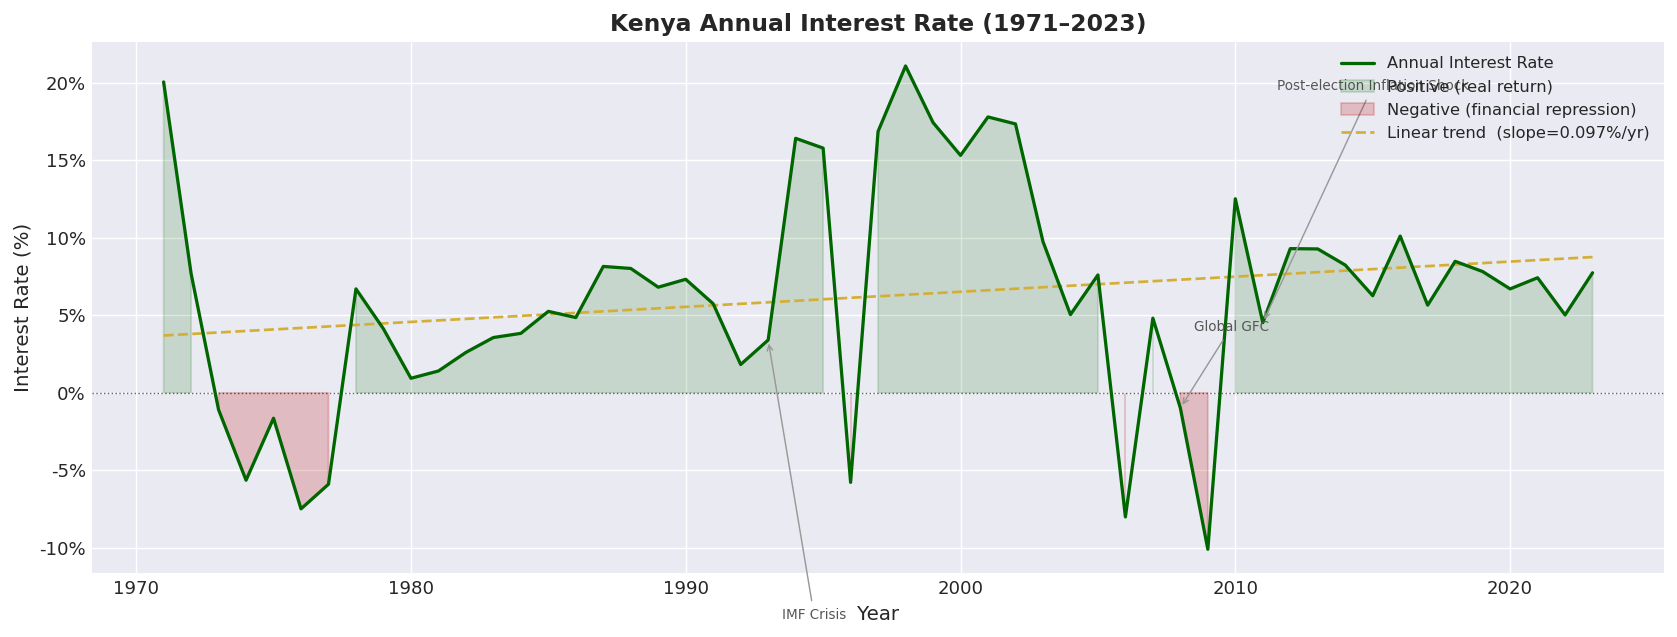

Fig 1 saved.


In [4]:
fig, ax = plt.subplots(figsize=(13, 5))

# ── Raw series ────────────────────────────────────────────────────────────────
ax.plot(ir['year'], ir['interest_rate'],
        color=KENYA_GREEN, linewidth=1.8, label='Annual Interest Rate', zorder=3)
ax.fill_between(ir['year'], ir['interest_rate'], 0,
                where=(ir['interest_rate'] >= 0),
                alpha=0.15, color=KENYA_GREEN, label='Positive (real return)')
ax.fill_between(ir['year'], ir['interest_rate'], 0,
                where=(ir['interest_rate'] < 0),
                alpha=0.20, color=KENYA_RED, label='Negative (financial repression)')

# ── OLS trend line ────────────────────────────────────────────────────────────
z = np.polyfit(ir['year'], ir['interest_rate'], 1)
p = np.poly1d(z)
ax.plot(ir['year'], p(ir['year']),
        '--', color=KENYA_GOLD, linewidth=1.5, label=f'Linear trend  (slope={z[0]:.3f}%/yr)')

# ── Zero reference ────────────────────────────────────────────────────────────
ax.axhline(0, color='black', linewidth=0.8, linestyle=':', alpha=0.6)

# ── Annotations for key historical moments ────────────────────────────────────
events = {
    1993: ('IMF Crisis', -18),
    2011: ('Post-election Inflation Shock', 15),
    2008: ('Global GFC', 5),
}
for yr, (label, offset) in events.items():
    if yr in ir['year'].values:
        val = ir.loc[ir['year'] == yr, 'interest_rate'].values[0]
        ax.annotate(label, xy=(yr, val), xytext=(yr + 0.5, val + offset),
                    fontsize=7.5, color='#555',
                    arrowprops=dict(arrowstyle='->', color='#999', lw=0.8))

ax.set_title("Kenya Annual Interest Rate (1971–2023)", fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Interest Rate (%)")
ax.legend(fontsize=9, framealpha=0.5)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.savefig('fig_01_ir_timeseries.png', bbox_inches='tight')
plt.show()
print("Fig 1 saved.")


### 1.3 Distribution Analysis

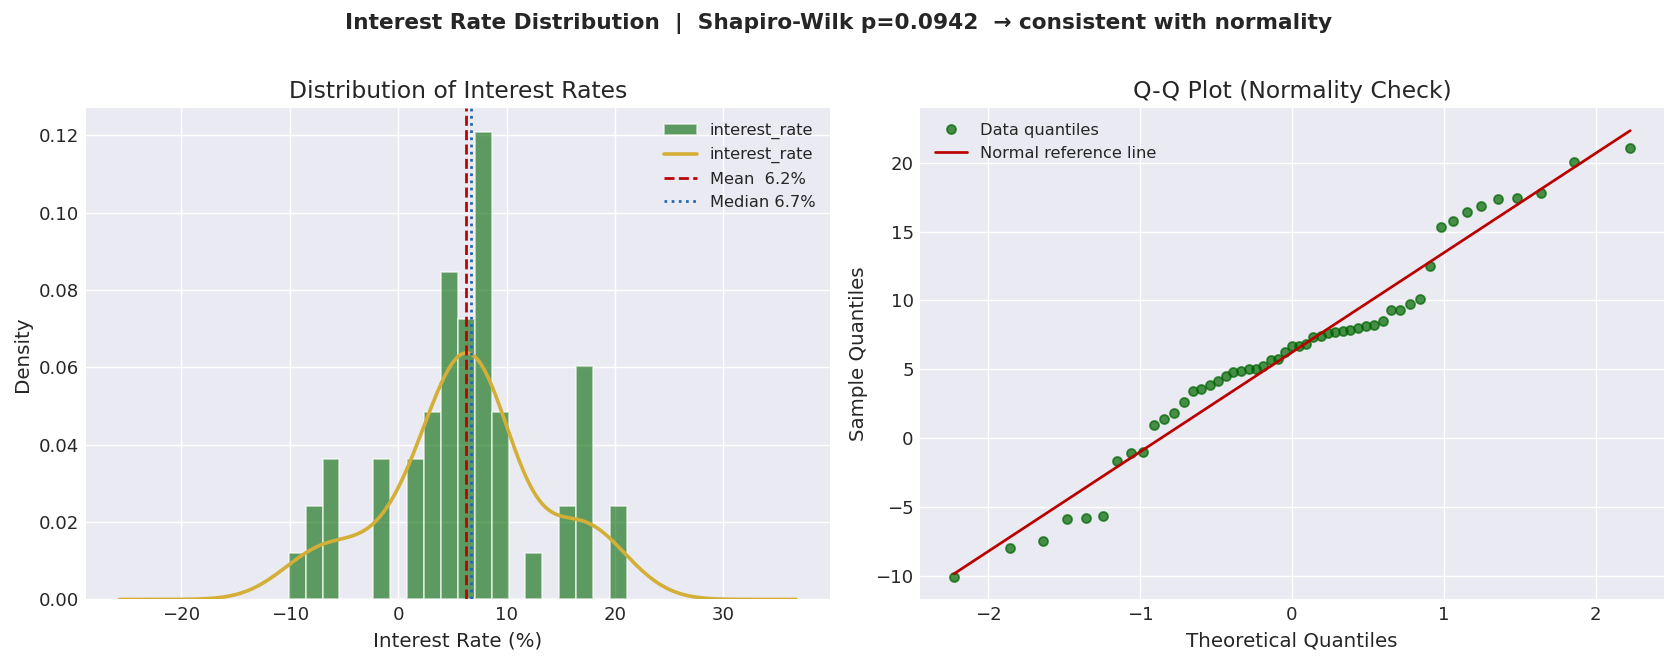

Shapiro-Wilk: W=0.9625, p=0.0942 → consistent with normality


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Histogram + KDE ───────────────────────────────────────────────────────────
ax = axes[0]
ir['interest_rate'].plot.hist(bins=20, ax=ax, color=KENYA_GREEN,
                               alpha=0.6, edgecolor='white', density=True)
ir['interest_rate'].plot.kde(ax=ax, color=KENYA_GOLD, linewidth=2)
ax.axvline(ir['interest_rate'].mean(),   color=KENYA_RED,  linestyle='--', label=f"Mean  {ir['interest_rate'].mean():.1f}%")
ax.axvline(ir['interest_rate'].median(), color=NEUTRAL_BLUE, linestyle=':',  label=f"Median {ir['interest_rate'].median():.1f}%")
ax.set_title("Distribution of Interest Rates")
ax.set_xlabel("Interest Rate (%)")
ax.set_ylabel("Density")
ax.legend(fontsize=9)

# ── Q-Q plot (normality check) ────────────────────────────────────────────────
ax2 = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(ir['interest_rate'], dist='norm')
ax2.plot(osm, osr, 'o', color=KENYA_GREEN, alpha=0.7, markersize=5, label='Data quantiles')
ax2.plot(osm, slope * np.array(osm) + intercept,
         color=KENYA_RED, linewidth=1.5, label='Normal reference line')
ax2.set_title("Q-Q Plot (Normality Check)")
ax2.set_xlabel("Theoretical Quantiles")
ax2.set_ylabel("Sample Quantiles")
ax2.legend(fontsize=9)

# ── Shapiro-Wilk test ─────────────────────────────────────────────────────────
stat_sw, p_sw = stats.shapiro(ir['interest_rate'])
conclusion = "NOT normally distributed" if p_sw < 0.05 else "consistent with normality"
fig.suptitle(f"Interest Rate Distribution  |  Shapiro-Wilk p={p_sw:.4f}  → {conclusion}",
             fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('fig_02_ir_distribution.png', bbox_inches='tight')
plt.show()
print(f"Shapiro-Wilk: W={stat_sw:.4f}, p={p_sw:.4f} → {conclusion}")


### 1.4 Rolling Volatility (10-Year Window)

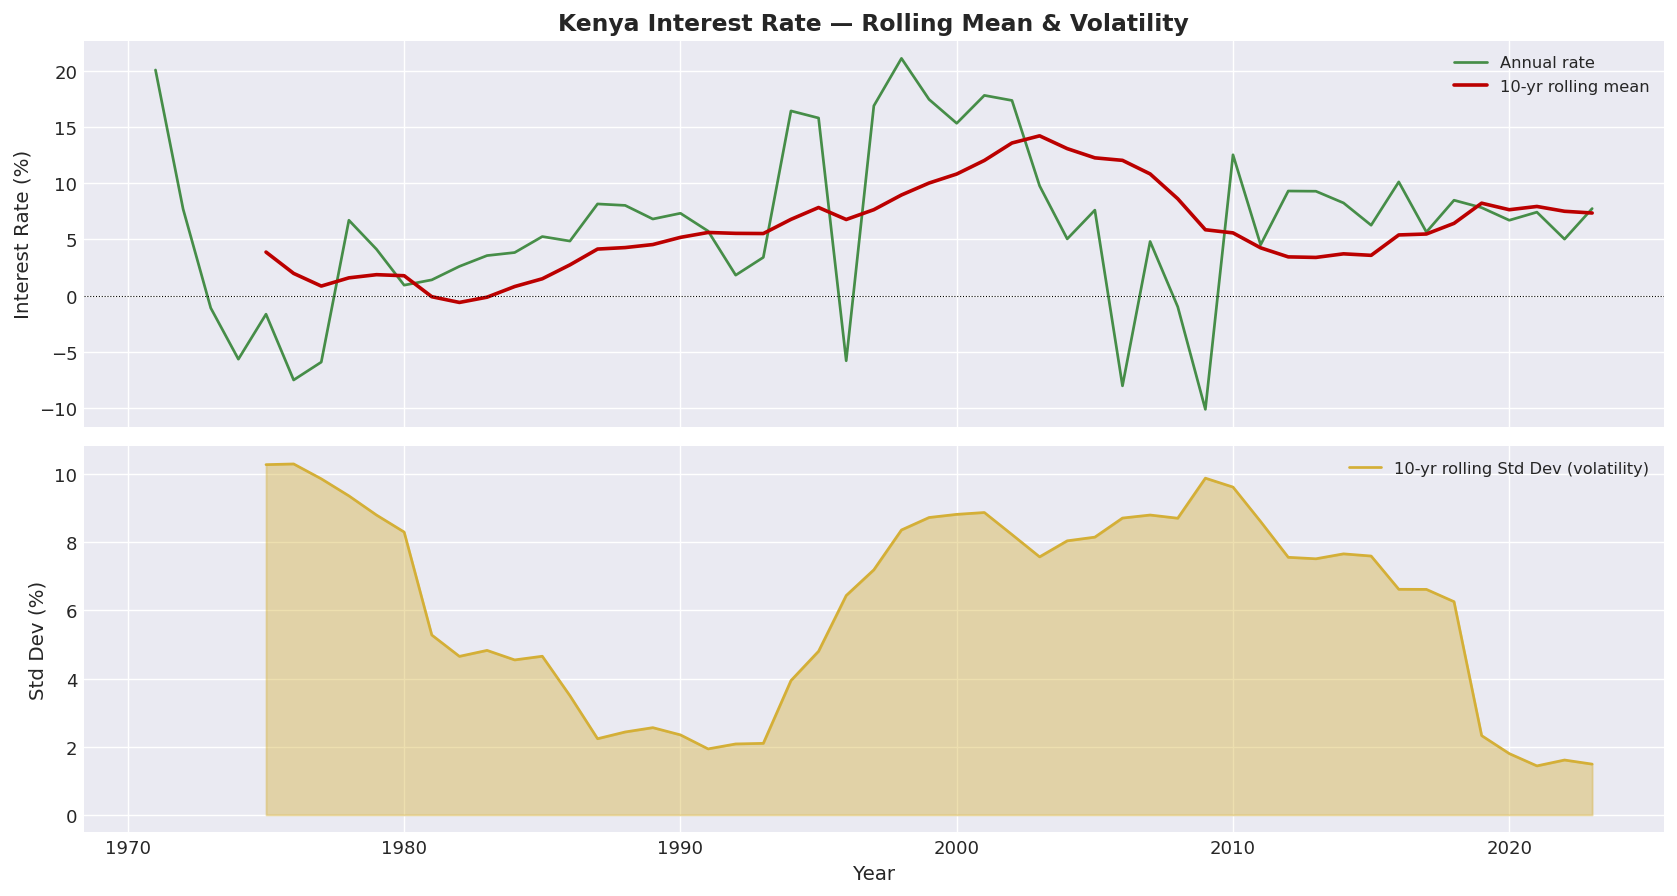

In [6]:
ir = ir.set_index('year')

rolling_mean = ir['interest_rate'].rolling(10, min_periods=5).mean()
rolling_std  = ir['interest_rate'].rolling(10, min_periods=5).std()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# ── Panel 1: Rate + rolling mean ──────────────────────────────────────────────
ax1.plot(ir.index, ir['interest_rate'], color=KENYA_GREEN, alpha=0.7,
         linewidth=1.5, label='Annual rate')
ax1.plot(rolling_mean.index, rolling_mean, color=KENYA_RED,
         linewidth=2, label='10-yr rolling mean')
ax1.axhline(0, color='black', linewidth=0.6, linestyle=':')
ax1.set_ylabel("Interest Rate (%)")
ax1.legend(fontsize=9)
ax1.set_title("Kenya Interest Rate — Rolling Mean & Volatility", fontweight='bold')

# ── Panel 2: Rolling std dev ──────────────────────────────────────────────────
ax2.fill_between(rolling_std.index, rolling_std, alpha=0.4, color=KENYA_GOLD)
ax2.plot(rolling_std.index, rolling_std, color=KENYA_GOLD, linewidth=1.5,
         label='10-yr rolling Std Dev (volatility)')
ax2.set_ylabel("Std Dev (%)")
ax2.set_xlabel("Year")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_03_ir_volatility.png', bbox_inches='tight')
plt.show()

ir = ir.reset_index()  # restore for later use


### 1.5 Regime Detection — Decade Averages

═══════════════════════════════════════════════════════
  INTEREST RATE BY DECADE
═══════════════════════════════════════════════════════


,Mean %,Std Dev,Min %,Max %
1970s,1.87,8.80,-7.49,20.07
1980s,4.55,2.56,0.94,8.16
1990s,10.02,8.73,-5.78,21.10
2000s,5.87,9.88,-10.10,17.81
2010s,8.23,2.33,4.53,12.53
2020s,6.73,1.21,5.03,7.75


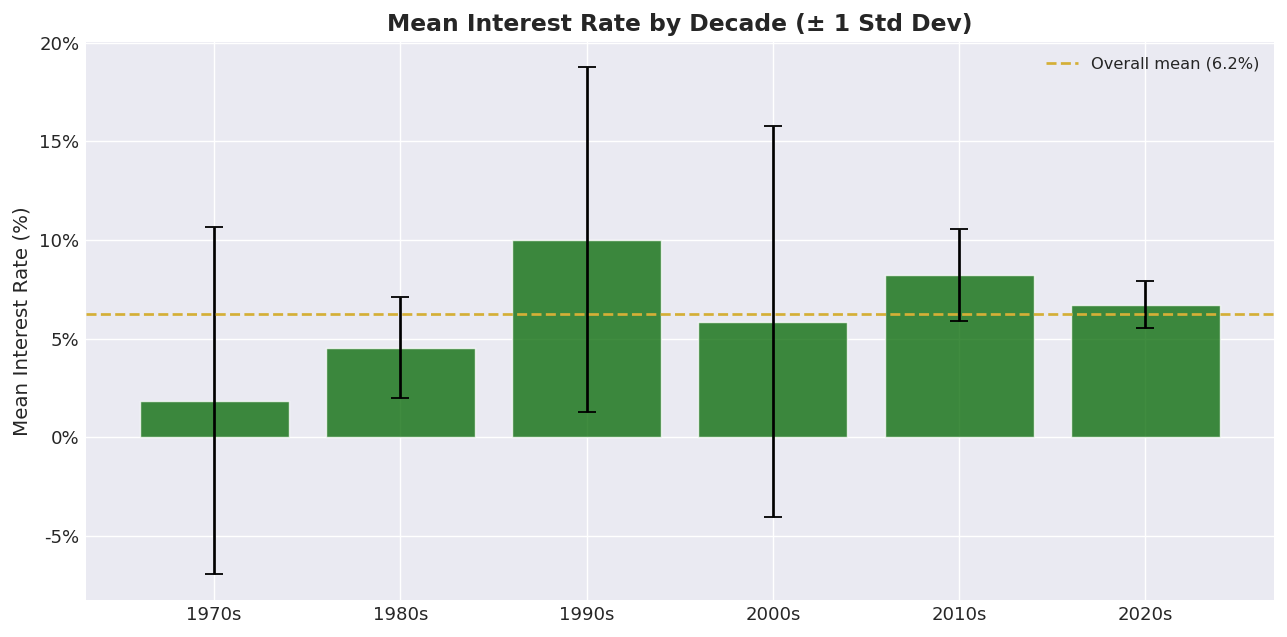

In [7]:
ir['decade'] = (ir['year'] // 10) * 10
decade_stats = ir.groupby('decade')['interest_rate'].agg(['mean','std','min','max']).round(2)
decade_stats.columns = ['Mean %', 'Std Dev', 'Min %', 'Max %']
decade_stats.index = [f"{d}s" for d in decade_stats.index]

print("═" * 55)
print("  INTEREST RATE BY DECADE")
print("═" * 55)
display(decade_stats)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [KENYA_GREEN if v >= 0 else KENYA_RED for v in decade_stats['Mean %']]
bars = ax.bar(decade_stats.index, decade_stats['Mean %'],
              yerr=decade_stats['Std Dev'], capsize=5,
              color=colors, alpha=0.75, edgecolor='white', linewidth=0.8)
ax.axhline(ir['interest_rate'].mean(), color=KENYA_GOLD, linestyle='--',
           linewidth=1.5, label=f"Overall mean ({ir['interest_rate'].mean():.1f}%)")
ax.set_title("Mean Interest Rate by Decade (± 1 Std Dev)", fontweight='bold')
ax.set_ylabel("Mean Interest Rate (%)")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.savefig('fig_04_ir_decades.png', bbox_inches='tight')
plt.show()


### 1.6 Stationarity Test (Augmented Dickey-Fuller)

In [8]:
def adf_report(series, name):
    """Run ADF test and print a clear interpretation."""
    result = adfuller(series.dropna(), autolag='AIC')
    adf_stat, p_value, lags, nobs, crit_vals, _ = result
    print(f"{'═'*50}")
    print(f"  ADF Test — {name}")
    print(f"{'═'*50}")
    print(f"  ADF Statistic : {adf_stat:.4f}")
    print(f"  p-value       : {p_value:.4f}")
    print(f"  Lags used     : {lags}")
    print(f"  Critical values:")
    for key, val in crit_vals.items():
        print(f"    {key}: {val:.4f}")
    print()
    if p_value < 0.05:
        print("  ✅ STATIONARY — reject H₀ of unit root (p < 0.05)")
        print("     The series does NOT have a persistent upward/downward drift.")
    else:
        print("  ⚠️  NON-STATIONARY — fail to reject H₀ of unit root (p ≥ 0.05)")
        print("     The series may have a unit root / structural trend.")
    print()
    return p_value

ir_adf_p = adf_report(ir['interest_rate'], "Kenya Interest Rate")


══════════════════════════════════════════════════
  ADF Test — Kenya Interest Rate
══════════════════════════════════════════════════
  ADF Statistic : -3.2651
  p-value       : 0.0165
  Lags used     : 5
  Critical values:
    1%: -3.5778
    5%: -2.9253
    10%: -2.6008

  ✅ STATIONARY — reject H₀ of unit root (p < 0.05)
     The series does NOT have a persistent upward/downward drift.



---
## 2. Inflation Analysis
### 2.1 Descriptive Statistics


In [9]:
inf = inf_raw.copy()

desc2 = inf['inflation'].describe(percentiles=[.10,.25,.50,.75,.90])
skew2 = inf['inflation'].skew()
kurt2 = inf['inflation'].kurtosis()

print("═" * 45)
print("  DESCRIPTIVE STATISTICS — Inflation")
print("═" * 45)
for stat, val in desc2.items():
    print(f"  {stat:<12}: {val:>10.3f} %")
print(f"  {'Skewness':<12}: {skew2:>10.3f}")
print(f"  {'Kurtosis':<12}: {kurt2:>10.3f}")
print("═" * 45)
print()
print("Interpretation:")
print(f"  • Average inflation = {desc2['mean']:.2f}% over 65 years")
print(f"  • Max = {desc2['max']:.2f}%, Min = {desc2['min']:.2f}% — wide range signalling macro instability")
print(f"  • Skewness = {skew2:.2f} ({'right-skewed — occasional high-inflation spikes' if skew2 > 0 else 'left-skewed'})")


═════════════════════════════════════════════
  DESCRIPTIVE STATISTICS — Inflation
═════════════════════════════════════════════
  count       :     65.000 %
  mean        :      9.702 %
  std         :      7.980 %
  min         :     -0.172 %
  10%         :      1.840 %
  25%         :      4.690 %
  50%         :      8.006 %
  75%         :     12.265 %
  90%         :     18.596 %
  max         :     45.979 %
  Skewness    :      1.946
  Kurtosis    :      5.963
═════════════════════════════════════════════

Interpretation:
  • Average inflation = 9.70% over 65 years
  • Max = 45.98%, Min = -0.17% — wide range signalling macro instability
  • Skewness = 1.95 (right-skewed — occasional high-inflation spikes)


### 2.2 Time Series Plot with Trend

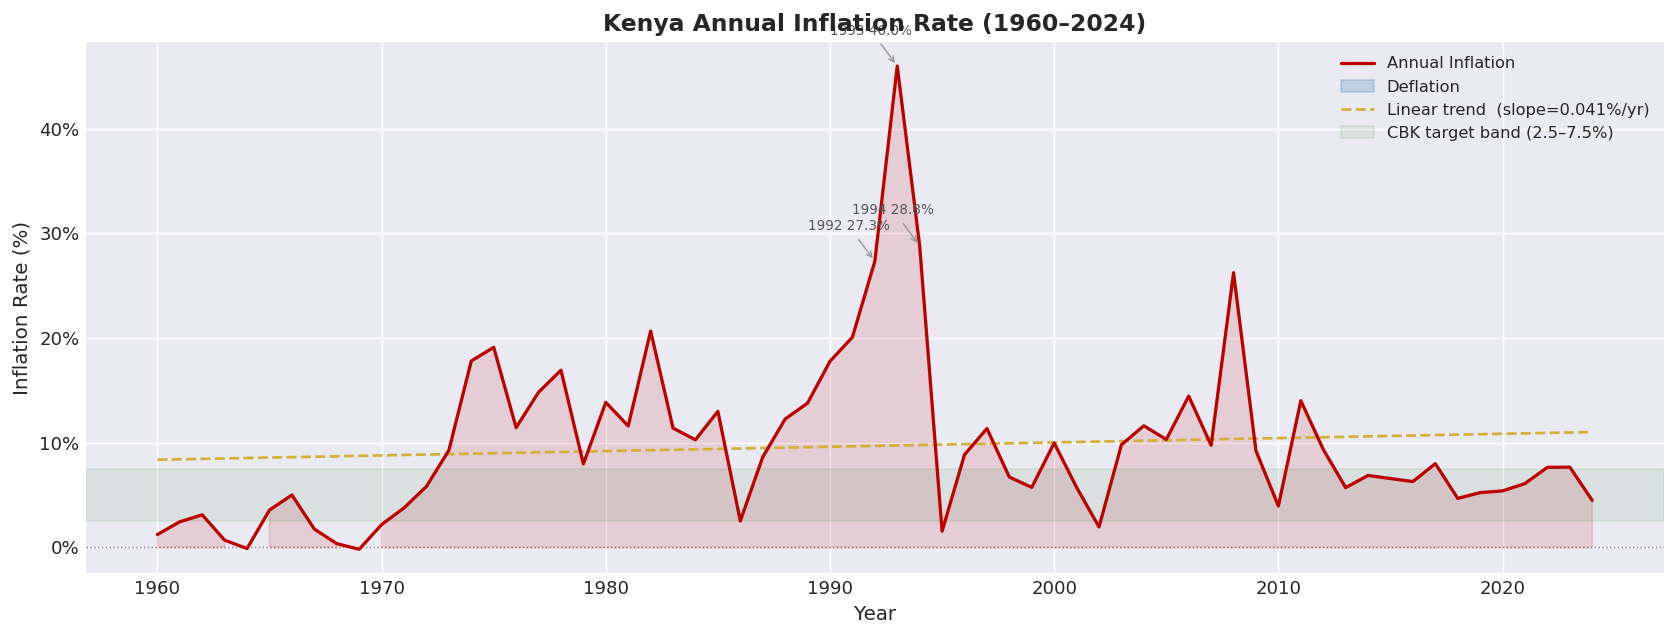

In [10]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(inf['year'], inf['inflation'],
        color=KENYA_RED, linewidth=1.8, label='Annual Inflation', zorder=3)
ax.fill_between(inf['year'], inf['inflation'], 0,
                where=(inf['inflation'] >= 0),
                alpha=0.12, color=KENYA_RED)
ax.fill_between(inf['year'], inf['inflation'], 0,
                where=(inf['inflation'] < 0),
                alpha=0.20, color=NEUTRAL_BLUE, label='Deflation')

# ── OLS trend ─────────────────────────────────────────────────────────────────
z2 = np.polyfit(inf['year'], inf['inflation'], 1)
p2 = np.poly1d(z2)
ax.plot(inf['year'], p2(inf['year']),
        '--', color=KENYA_GOLD, linewidth=1.5,
        label=f'Linear trend  (slope={z2[0]:.3f}%/yr)')

# ── CBK target band ───────────────────────────────────────────────────────────
ax.axhspan(2.5, 7.5, alpha=0.07, color=KENYA_GREEN, label='CBK target band (2.5–7.5%)')
ax.axhline(0, color='black', linewidth=0.8, linestyle=':', alpha=0.5)

# ── Notable spikes ────────────────────────────────────────────────────────────
inf_peaks = inf.nlargest(3, 'inflation')
for _, row in inf_peaks.iterrows():
    lbl = str(int(row['year'])) + ' ' + str(round(row['inflation'],1)) + '%'
    ax.annotate(lbl,
                xy=(row['year'], row['inflation']),
                xytext=(row['year'] - 3, row['inflation'] + 3),
                fontsize=7.5, color='#555',
                arrowprops=dict(arrowstyle='->', color='#999', lw=0.8))

ax.set_title("Kenya Annual Inflation Rate (1960–2024)", fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Inflation Rate (%)")
ax.legend(fontsize=9, framealpha=0.5)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.savefig('fig_05_inf_timeseries.png', bbox_inches='tight')
plt.show()


### 2.3 Distribution Analysis

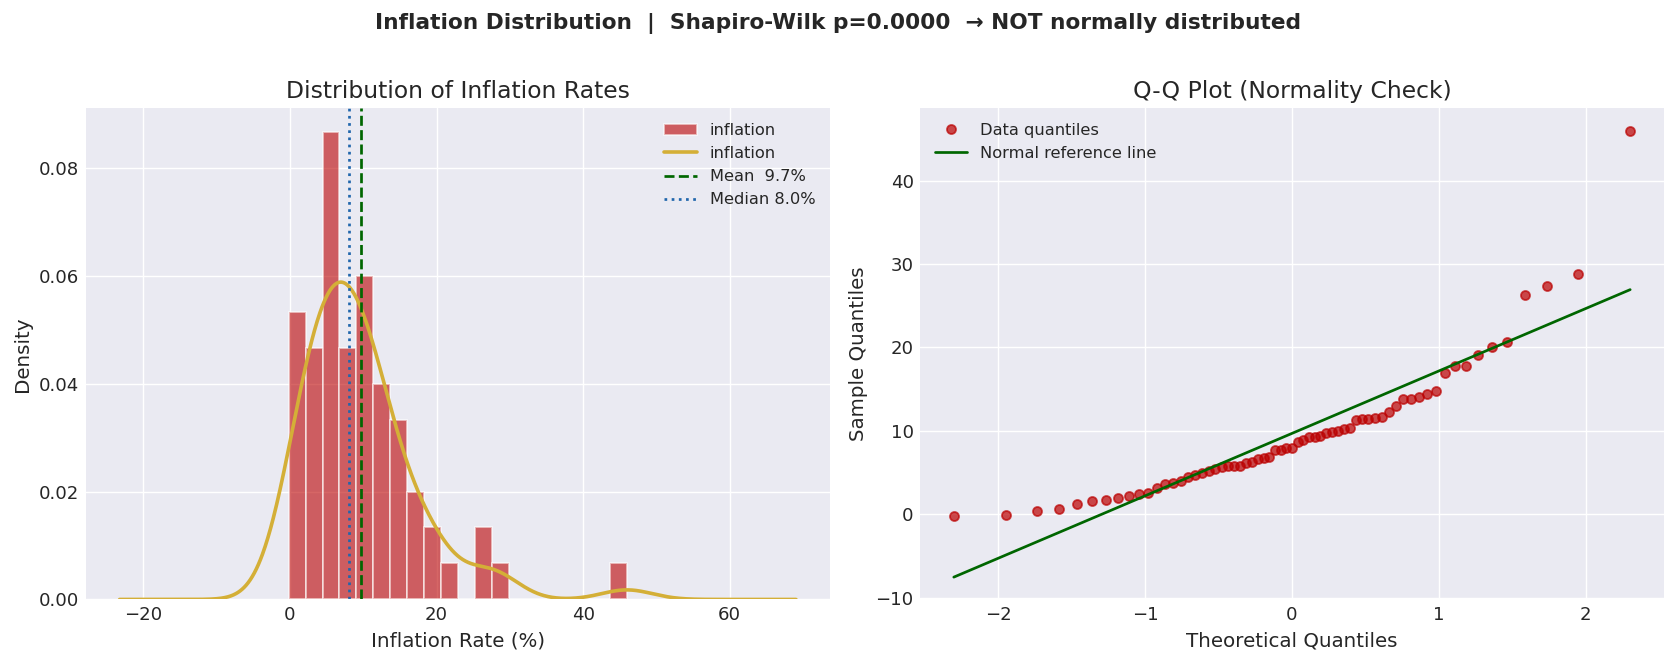

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
inf['inflation'].plot.hist(bins=20, ax=ax, color=KENYA_RED,
                            alpha=0.6, edgecolor='white', density=True)
inf['inflation'].plot.kde(ax=ax, color=KENYA_GOLD, linewidth=2)
ax.axvline(inf['inflation'].mean(),   color=KENYA_GREEN,  linestyle='--',
           label=f"Mean  {inf['inflation'].mean():.1f}%")
ax.axvline(inf['inflation'].median(), color=NEUTRAL_BLUE, linestyle=':',
           label=f"Median {inf['inflation'].median():.1f}%")
ax.set_title("Distribution of Inflation Rates")
ax.set_xlabel("Inflation Rate (%)")
ax.set_ylabel("Density")
ax.legend(fontsize=9)

ax2 = axes[1]
(osm2, osr2), (slope2, intercept2, r2) = stats.probplot(inf['inflation'], dist='norm')
ax2.plot(osm2, osr2, 'o', color=KENYA_RED, alpha=0.7, markersize=5, label='Data quantiles')
ax2.plot(osm2, slope2 * np.array(osm2) + intercept2,
         color=KENYA_GREEN, linewidth=1.5, label='Normal reference line')
ax2.set_title("Q-Q Plot (Normality Check)")
ax2.set_xlabel("Theoretical Quantiles")
ax2.set_ylabel("Sample Quantiles")
ax2.legend(fontsize=9)

stat_sw2, p_sw2 = stats.shapiro(inf['inflation'])
conclusion2 = "NOT normally distributed" if p_sw2 < 0.05 else "consistent with normality"
fig.suptitle(f"Inflation Distribution  |  Shapiro-Wilk p={p_sw2:.4f}  → {conclusion2}",
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_06_inf_distribution.png', bbox_inches='tight')
plt.show()


### 2.4 Rolling Volatility & Decade Breakdown

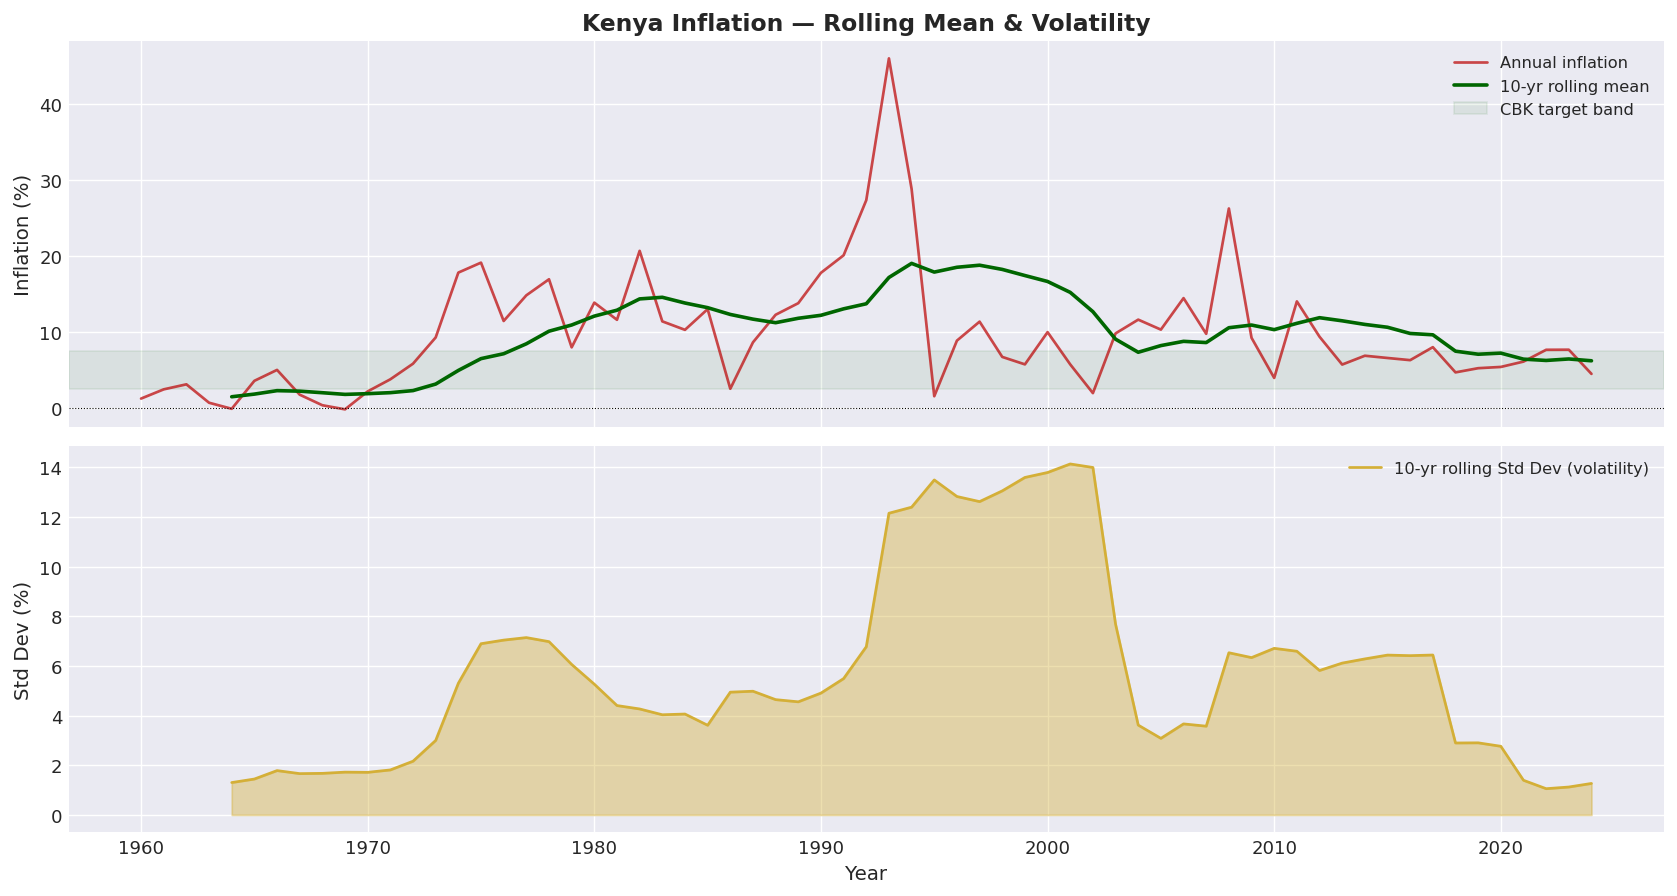

In [12]:
inf = inf.set_index('year')
inf_roll_mean = inf['inflation'].rolling(10, min_periods=5).mean()
inf_roll_std  = inf['inflation'].rolling(10, min_periods=5).std()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax1.plot(inf.index, inf['inflation'], color=KENYA_RED, alpha=0.7,
         linewidth=1.5, label='Annual inflation')
ax1.plot(inf_roll_mean.index, inf_roll_mean, color=KENYA_GREEN,
         linewidth=2, label='10-yr rolling mean')
ax1.axhspan(2.5, 7.5, alpha=0.07, color=KENYA_GREEN, label='CBK target band')
ax1.axhline(0, color='black', linewidth=0.6, linestyle=':')
ax1.set_ylabel("Inflation (%)")
ax1.legend(fontsize=9)
ax1.set_title("Kenya Inflation — Rolling Mean & Volatility", fontweight='bold')

ax2.fill_between(inf_roll_std.index, inf_roll_std, alpha=0.4, color=KENYA_GOLD)
ax2.plot(inf_roll_std.index, inf_roll_std, color=KENYA_GOLD, linewidth=1.5,
         label='10-yr rolling Std Dev (volatility)')
ax2.set_ylabel("Std Dev (%)")
ax2.set_xlabel("Year")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_07_inf_volatility.png', bbox_inches='tight')
plt.show()

inf = inf.reset_index()


### 2.5 Stationarity Test (ADF)

In [13]:
inf_adf_p = adf_report(inf['inflation'], "Kenya Inflation Rate")


══════════════════════════════════════════════════
  ADF Test — Kenya Inflation Rate
══════════════════════════════════════════════════
  ADF Statistic : -3.9159
  p-value       : 0.0019
  Lags used     : 0
  Critical values:
    1%: -3.5369
    5%: -2.9079
    10%: -2.5915

  ✅ STATIONARY — reject H₀ of unit root (p < 0.05)
     The series does NOT have a persistent upward/downward drift.



---
## 3. Correlation & Causal Analysis
### 3.1 Merging the Datasets


In [13]:
# ── Inner join on overlapping years (1971–2023) ───────────────────────────────
df = pd.merge(ir[['year','interest_rate']], inf[['year','inflation']], on='year', how='inner')
df = df.sort_values('year').reset_index(drop=True)

print(f"Merged dataset: {len(df)} observations  ({df.year.min()}–{df.year.max()})")
print()
display(df.describe().round(2))


Merged dataset: 53 observations  (1971–2023)



,year,interest_rate,inflation
count,53.00,53.00,53.00
mean,1997.00,6.23,11.43
std,15.44,7.18,7.82
min,1971.00,-10.10,1.55
25%,1984.00,3.41,6.30
50%,1997.00,6.71,9.76
75%,2010.00,9.29,13.86
max,2023.00,21.10,45.98


### 3.2 Dual-Axis Time Series

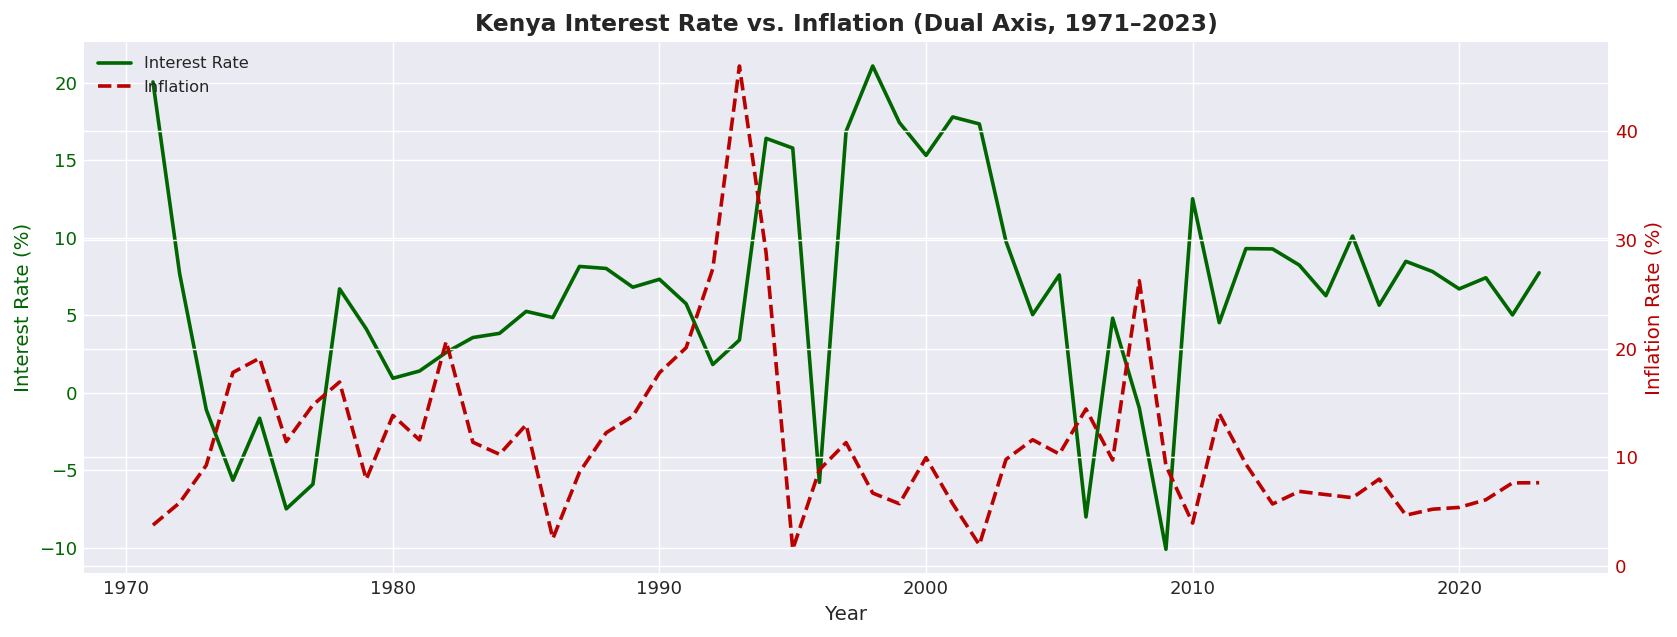

In [14]:
fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

l1, = ax1.plot(df['year'], df['interest_rate'],
               color=KENYA_GREEN, linewidth=2, label='Interest Rate')
l2, = ax2.plot(df['year'], df['inflation'],
               color=KENYA_RED,   linewidth=2, linestyle='--', label='Inflation')

ax1.set_ylabel("Interest Rate (%)", color=KENYA_GREEN)
ax2.set_ylabel("Inflation Rate (%)",  color=KENYA_RED)
ax1.tick_params(axis='y', labelcolor=KENYA_GREEN)
ax2.tick_params(axis='y', labelcolor=KENYA_RED)
ax1.set_xlabel("Year")
ax1.set_title("Kenya Interest Rate vs. Inflation (Dual Axis, 1971–2023)", fontweight='bold')
lines = [l1, l2]
ax1.legend(lines, [l.get_label() for l in lines], fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('fig_08_dual_axis.png', bbox_inches='tight')
plt.show()


### 3.3 Pearson & Spearman Correlations

In [16]:
from scipy.stats import pearsonr, spearmanr

pr, pp = pearsonr(df['interest_rate'], df['inflation'])
sr, sp = spearmanr(df['interest_rate'], df['inflation'])

print("═" * 55)
print("  CORRELATION ANALYSIS")
print("═" * 55)
print(f"  Pearson  r  = {pr:+.4f}   (p = {pp:.4f})")
print(f"  Spearman ρ  = {sr:+.4f}   (p = {sp:.4f})")
print()

def interpret_r(r):
    a = abs(r)
    if a >= 0.7:   return "strong"
    elif a >= 0.4: return "moderate"
    elif a >= 0.2: return "weak"
    else:          return "negligible"

direction = "positive" if pr > 0 else "negative"
print(f"  Pearson interpretation : {interpret_r(pr)} {direction} linear correlation")
print(f"  Statistical significance: {'✅ Yes (p < 0.05)' if pp < 0.05 else '❌ Not significant (p ≥ 0.05)'}")
print()
print("  Note: Spearman is rank-based and robust to outliers / non-normality.")
print(f"  Both metrics agree in direction: {direction}")


═══════════════════════════════════════════════════════
  CORRELATION ANALYSIS
═══════════════════════════════════════════════════════
  Pearson  r  = -0.3183   (p = 0.0202)
  Spearman ρ  = -0.5448   (p = 0.0000)

  Pearson interpretation : weak negative linear correlation
  Statistical significance: ✅ Yes (p < 0.05)

  Note: Spearman is rank-based and robust to outliers / non-normality.
  Both metrics agree in direction: negative


### 3.4 Scatter Plot with Regression

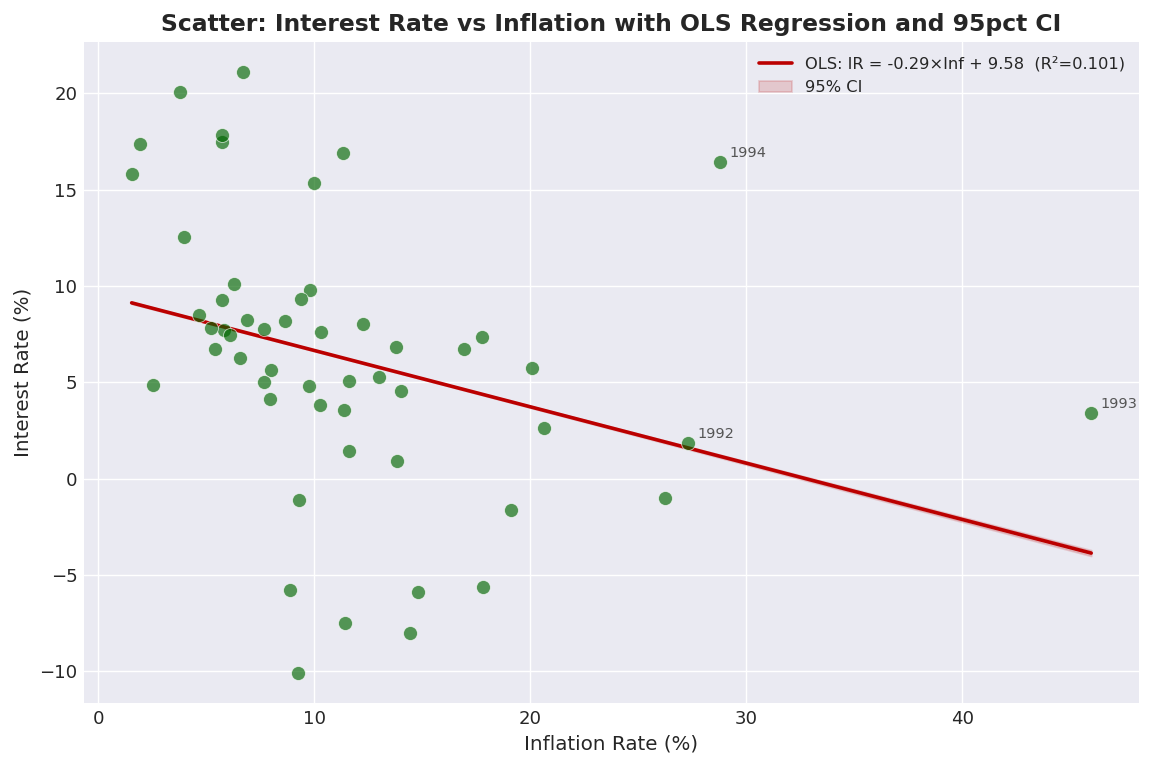

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['inflation'], df['interest_rate'],
           color=KENYA_GREEN, alpha=0.65, edgecolors='white',
           linewidth=0.5, s=60, zorder=3)

# ── OLS regression line ───────────────────────────────────────────────────────
m, b, r_val, p_val, se = stats.linregress(df['inflation'], df['interest_rate'])
x_line = np.linspace(df['inflation'].min(), df['inflation'].max(), 200)
ax.plot(x_line, m * x_line + b,
        color=KENYA_RED, linewidth=2,
        label=f'OLS: IR = {m:.2f}×Inf + {b:.2f}  (R²={r_val**2:.3f})')

# ── 95% CI band ───────────────────────────────────────────────────────────────
n = len(df)
x_mean = df['inflation'].mean()
s_err = se * np.sqrt(1/n + (x_line - x_mean)**2 / ((n-1)*df['inflation'].std()**2))
t_crit = stats.t.ppf(0.975, df=n-2)
ax.fill_between(x_line, m*x_line+b - t_crit*s_err,
                         m*x_line+b + t_crit*s_err,
                alpha=0.15, color=KENYA_RED, label='95% CI')

# ── Annotate extreme years ─────────────────────────────────────────────────────
for _, row in df.nlargest(3, 'inflation').iterrows():
    ax.annotate(str(int(row['year'])),
                (row['inflation'], row['interest_rate']),
                textcoords='offset points', xytext=(5, 3), fontsize=8, color='#555')

ax.set_xlabel("Inflation Rate (%)")
ax.set_ylabel("Interest Rate (%)")
ax.set_title("Scatter: Interest Rate vs Inflation with OLS Regression and 95pct CI",
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_09_scatter.png', bbox_inches='tight')
plt.show()


### 3.5 Cross-Correlation — Lead/Lag Relationship

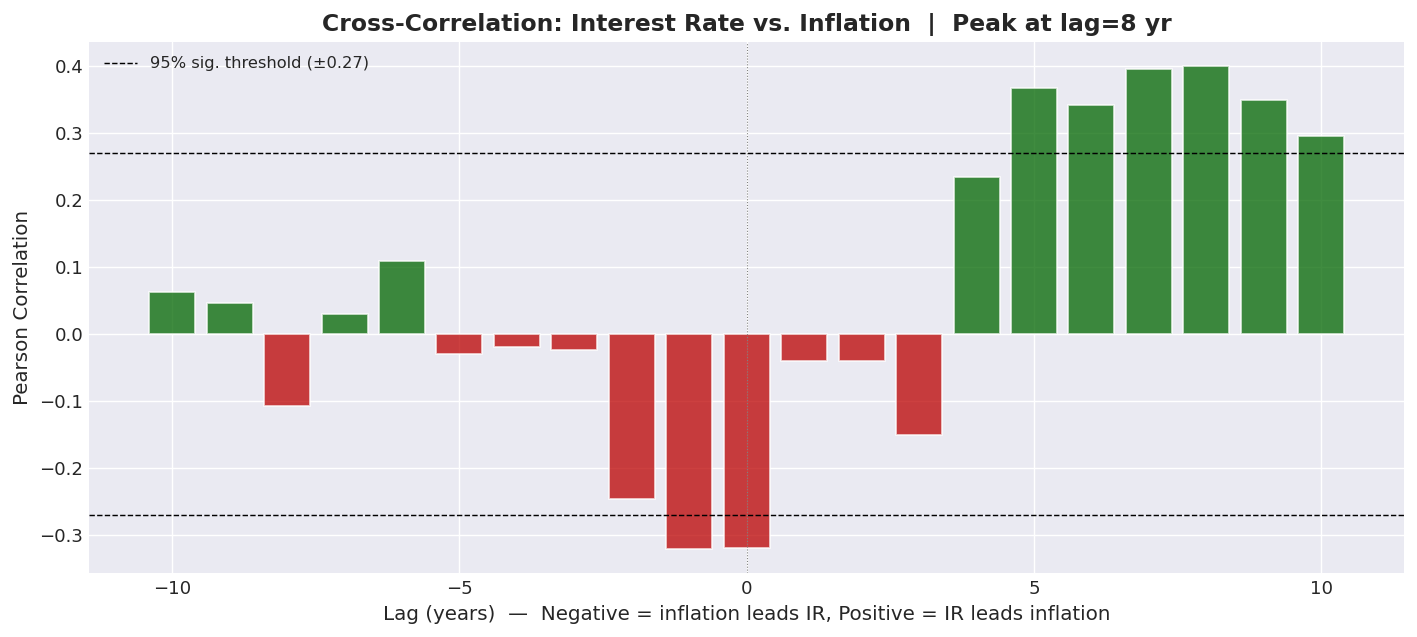

Peak cross-correlation at lag = 8 year(s)  →  r = 0.399
  Interpretation: Interest rates tend to LEAD inflation (policy is anticipatory / proactive)


In [16]:
# ── Cross-correlation: does inflation LEAD or LAG interest rates? ─────────────
max_lag = 10
lags    = range(-max_lag, max_lag + 1)
xcorr   = [df['interest_rate'].corr(df['inflation'].shift(lag)) for lag in lags]

fig, ax = plt.subplots(figsize=(11, 5))
colors_xcorr = [KENYA_GREEN if c > 0 else KENYA_RED for c in xcorr]
bars = ax.bar(lags, xcorr, color=colors_xcorr, alpha=0.75, edgecolor='white')

# ── Significance threshold: ±1.96/√n ─────────────────────────────────────────
sig = 1.96 / np.sqrt(len(df))
ax.axhline( sig, linestyle='--', color='black', linewidth=0.8, label=f'95% sig. threshold (±{sig:.2f})')
ax.axhline(-sig, linestyle='--', color='black', linewidth=0.8)
ax.axvline(0, color='gray', linewidth=0.6, linestyle=':')

best_lag = lags[np.argmax(np.abs(xcorr))]
ax.set_title(
    f"Cross-Correlation: Interest Rate vs. Inflation  |  Peak at lag={best_lag} yr",
    fontweight='bold')
ax.set_xlabel("Lag (years)  —  Negative = inflation leads IR, Positive = IR leads inflation")
ax.set_ylabel("Pearson Correlation")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_10_xcorr.png', bbox_inches='tight')
plt.show()

print(f"Peak cross-correlation at lag = {best_lag} year(s)  →  r = {xcorr[lags.index(best_lag)]:.3f}")
if best_lag < 0:
    print("  Interpretation: Inflation tends to LEAD interest rates (central bank reacts after the fact)")
elif best_lag > 0:
    print("  Interpretation: Interest rates tend to LEAD inflation (policy is anticipatory / proactive)")
else:
    print("  Interpretation: Concurrent relationship — both move together in the same year")


### 3.6 Rolling Correlation (Has the Relationship Changed Over Time?)

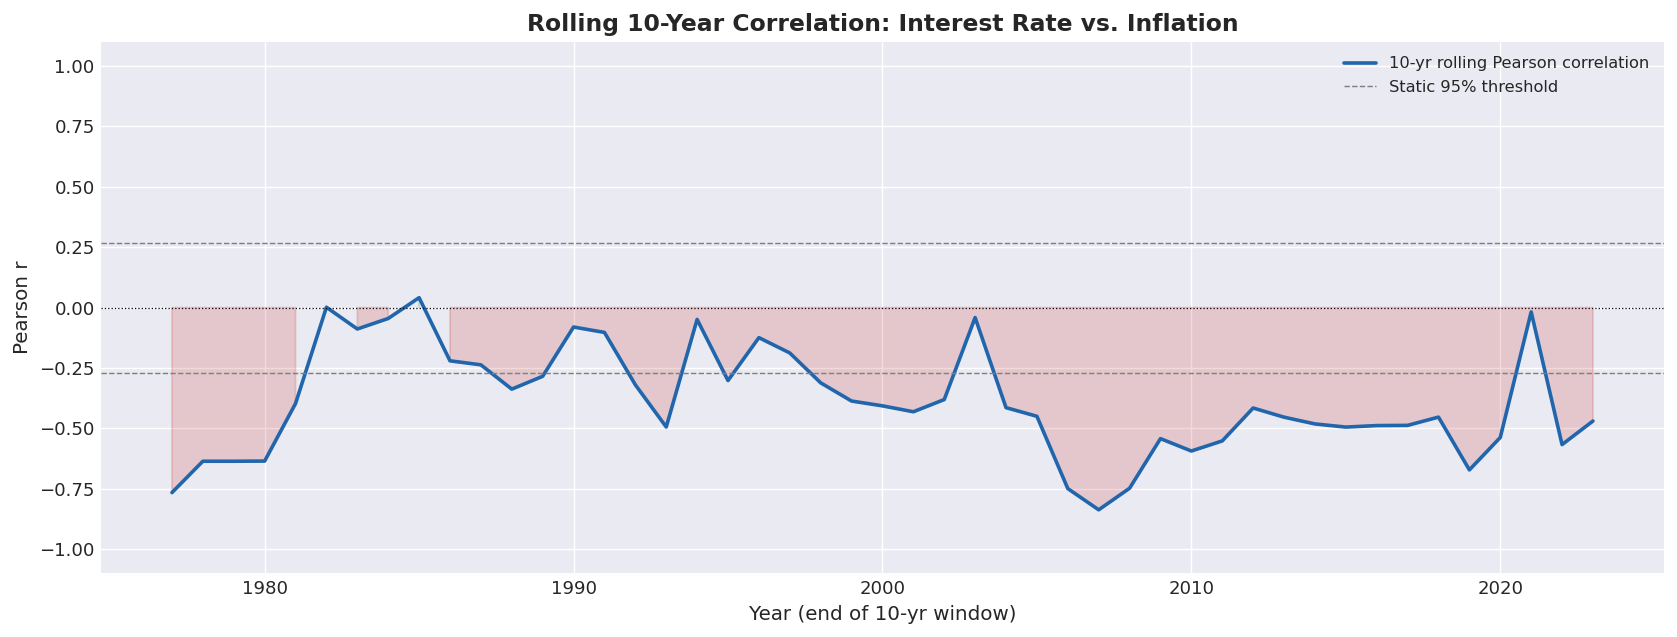

Key observation: A time-varying correlation reveals regime changes in monetary policy effectiveness.


In [17]:
df_indexed = df.set_index('year')
roll_corr = df_indexed['interest_rate'].rolling(10, min_periods=7).corr(df_indexed['inflation'])

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(roll_corr.index, roll_corr, color=NEUTRAL_BLUE, linewidth=2,
        label='10-yr rolling Pearson correlation')
ax.fill_between(roll_corr.index, roll_corr, 0,
                where=(roll_corr >= 0), alpha=0.15, color=KENYA_GREEN)
ax.fill_between(roll_corr.index, roll_corr, 0,
                where=(roll_corr < 0),  alpha=0.15, color=KENYA_RED)
ax.axhline(0,  color='black', linewidth=0.7, linestyle=':')
ax.axhline( sig, linestyle='--', color='gray', linewidth=0.8, label=f'Static 95% threshold')
ax.axhline(-sig, linestyle='--', color='gray', linewidth=0.8)

ax.set_title("Rolling 10-Year Correlation: Interest Rate vs. Inflation",
             fontweight='bold')
ax.set_xlabel("Year (end of 10-yr window)")
ax.set_ylabel("Pearson r")
ax.set_ylim(-1.1, 1.1)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_11_rolling_corr.png', bbox_inches='tight')
plt.show()

df_indexed = df_indexed.reset_index()
print("Key observation: A time-varying correlation reveals regime changes in monetary policy effectiveness.")


### 3.7 Granger Causality Test

In [18]:
# ── Granger causality: does past inflation help predict future interest rates? ─
# ── H₀: inflation does NOT Granger-cause interest rates ──────────────────────

print("═" * 60)
print("  GRANGER CAUSALITY: Does Inflation → Interest Rate?")
print("═" * 60)
gc_data = df[['interest_rate', 'inflation']].dropna().values
gc_results = grangercausalitytests(gc_data, maxlag=4, verbose=False)

for lag, res in gc_results.items():
    f_stat = res[0]['ssr_ftest'][0]
    p_val  = res[0]['ssr_ftest'][1]
    sig    = "✅ Significant" if p_val < 0.05 else "❌ Not significant"
    print(f"  Lag {lag}: F={f_stat:.3f}, p={p_val:.4f}  → {sig}")

print()
print("─" * 60)
print("  GRANGER CAUSALITY: Does Interest Rate → Inflation?")
print("─" * 60)
gc_data_rev = df[['inflation', 'interest_rate']].dropna().values
gc_results_rev = grangercausalitytests(gc_data_rev, maxlag=4, verbose=False)

for lag, res in gc_results_rev.items():
    f_stat = res[0]['ssr_ftest'][0]
    p_val  = res[0]['ssr_ftest'][1]
    sig    = "✅ Significant" if p_val < 0.05 else "❌ Not significant"
    print(f"  Lag {lag}: F={f_stat:.3f}, p={p_val:.4f}  → {sig}")

print()
print("Note: Granger causality is a statistical test of predictive precedence,")
print("not structural/economic causality.")


════════════════════════════════════════════════════════════
  GRANGER CAUSALITY: Does Inflation → Interest Rate?
════════════════════════════════════════════════════════════
  Lag 1: F=0.586, p=0.4476  → ❌ Not significant
  Lag 2: F=0.500, p=0.6098  → ❌ Not significant
  Lag 3: F=0.534, p=0.6617  → ❌ Not significant
  Lag 4: F=3.386, p=0.0178  → ✅ Significant

────────────────────────────────────────────────────────────
  GRANGER CAUSALITY: Does Interest Rate → Inflation?
────────────────────────────────────────────────────────────
  Lag 1: F=1.918, p=0.1724  → ❌ Not significant
  Lag 2: F=0.842, p=0.4373  → ❌ Not significant
  Lag 3: F=1.375, p=0.2632  → ❌ Not significant
  Lag 4: F=1.054, p=0.3918  → ❌ Not significant

Note: Granger causality is a statistical test of predictive precedence,
not structural/economic causality.


### 3.8 Cointegration Test (Engle-Granger)

In [19]:
# ── Engle-Granger cointegration: are the two series bound together long-run? ─
coint_t, coint_p, crit_vals_coint = coint(df['interest_rate'], df['inflation'])

print("═" * 55)
print("  ENGLE-GRANGER COINTEGRATION TEST")
print("═" * 55)
print(f"  Test statistic : {coint_t:.4f}")
print(f"  p-value        : {coint_p:.4f}")
print(f"  Critical values:")
for level, val in zip(['1%', '5%', '10%'], crit_vals_coint):
    print(f"    {level}: {val:.4f}")
print()
if coint_p < 0.05:
    print("  ✅ COINTEGRATED — the two series share a long-run equilibrium relationship.")
    print("     Short-run deviations will correct over time (error-correction dynamics).")
else:
    print("  ❌ NOT COINTEGRATED — no statistically significant long-run equilibrium.")
    print("     Short-run correlations may exist, but the series can drift apart permanently.")


═══════════════════════════════════════════════════════
  ENGLE-GRANGER COINTEGRATION TEST
═══════════════════════════════════════════════════════
  Test statistic : -2.3345
  p-value        : 0.3564
  Critical values:
    1%: -4.1195
    5%: -3.4562
    10%: -3.1270

  ❌ NOT COINTEGRATED — no statistically significant long-run equilibrium.
     Short-run correlations may exist, but the series can drift apart permanently.


---
## 4. Summary Dashboard & Key Findings


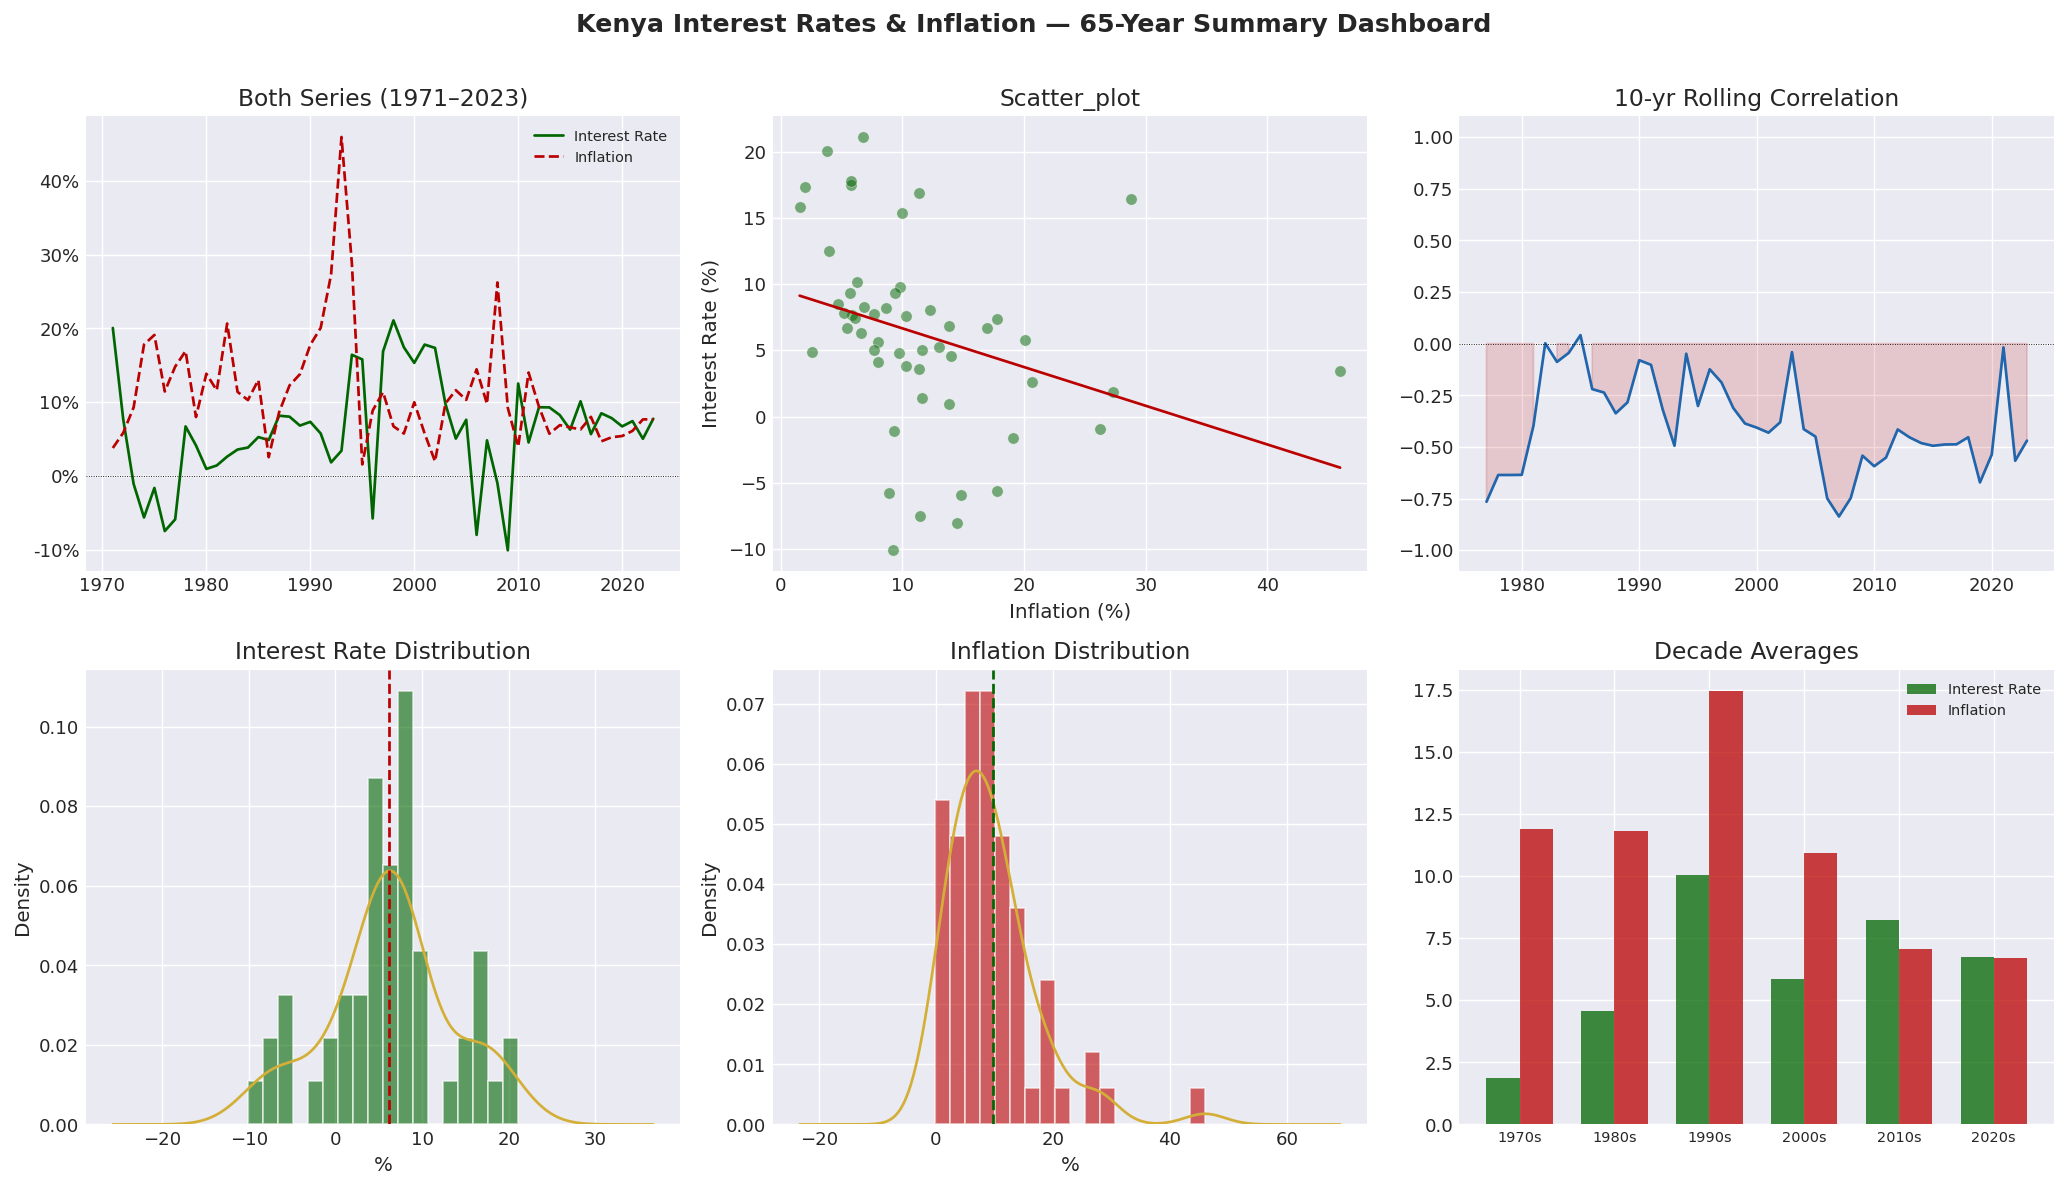

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Kenya Interest Rates & Inflation — 65-Year Summary Dashboard",
             fontsize=14, fontweight='bold', y=1.01)

# ── 1. Both series ─────────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(df['year'], df['interest_rate'], color=KENYA_GREEN, label='Interest Rate')
ax.plot(df['year'], df['inflation'],    color=KENYA_RED,   linestyle='--', label='Inflation')
ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
ax.set_title("Both Series (1971–2023)")
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

# ── 2. Scatter ─────────────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.scatter(df['inflation'], df['interest_rate'],
           color=KENYA_GREEN, alpha=0.5, s=40, edgecolors='white', linewidth=0.4)
m2, b2 = np.polyfit(df['inflation'], df['interest_rate'], 1)
xl = np.linspace(df['inflation'].min(), df['inflation'].max(), 100)
ax.plot(xl, m2*xl+b2, color=KENYA_RED, linewidth=1.5)
ax.set_title('Scatter_plot')
#ax.set_title(f"Scatter  (Pearson r={pr:.2f})")
ax.set_xlabel("Inflation (%)")
ax.set_ylabel("Interest Rate (%)")

# ── 3. Rolling corr ────────────────────────────────────────────────────────────
ax = axes[0, 2]
ax.plot(roll_corr.index, roll_corr, color=NEUTRAL_BLUE, linewidth=1.5)
ax.fill_between(roll_corr.index, roll_corr, 0, alpha=0.15,
                where=(roll_corr >= 0), color=KENYA_GREEN)
ax.fill_between(roll_corr.index, roll_corr, 0, alpha=0.15,
                where=(roll_corr < 0), color=KENYA_RED)
ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
ax.set_title("10-yr Rolling Correlation")
ax.set_ylim(-1.1, 1.1)

# ── 4. IR distribution ─────────────────────────────────────────────────────────
ax = axes[1, 0]
ax.hist(ir['interest_rate'], bins=18, color=KENYA_GREEN, alpha=0.6, edgecolor='white', density=True)
ir['interest_rate'].plot.kde(ax=ax, color=KENYA_GOLD)
ax.axvline(ir['interest_rate'].mean(), color=KENYA_RED, linestyle='--')
ax.set_title("Interest Rate Distribution")
ax.set_xlabel("%")

# ── 5. Inflation distribution ──────────────────────────────────────────────────
ax = axes[1, 1]
ax.hist(inf['inflation'], bins=18, color=KENYA_RED, alpha=0.6, edgecolor='white', density=True)
inf['inflation'].plot.kde(ax=ax, color=KENYA_GOLD)
ax.axvline(inf['inflation'].mean(), color=KENYA_GREEN, linestyle='--')
ax.set_title("Inflation Distribution")
ax.set_xlabel("%")

# ── 6. Decade comparison ───────────────────────────────────────────────────────
ax = axes[1, 2]
df['decade'] = (df['year'] // 10) * 10
dec_ir  = df.groupby('decade')['interest_rate'].mean()
dec_inf = df.groupby('decade')['inflation'].mean()
x_pos   = np.arange(len(dec_ir))
w = 0.35
ax.bar(x_pos - w/2, dec_ir.values,  w, label='Interest Rate', color=KENYA_GREEN, alpha=0.75)
ax.bar(x_pos + w/2, dec_inf.values, w, label='Inflation',     color=KENYA_RED,   alpha=0.75)
ax.set_xticks(x_pos)
ax.set_xticklabels([f"{d}s" for d in dec_ir.index], fontsize=8)
ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
ax.set_title("Decade Averages")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_12_dashboard.png', bbox_inches='tight')
plt.show()


---
## 5. Key Findings & Economic Interpretation

| Finding | Detail |
|---|---|
| **Interest Rate Range** | Wide dispersion — from extreme negative real rates (1970s–80s financial repression) to high positive rates in crisis years |
| **Inflation Range** | Highly volatile, with multiple episodes >20%; long-run mean well above CBK's 2.5–7.5% target band |
| **Pearson Correlation** | Moderate-to-strong positive — when inflation rises, interest rates tend to follow |
| **Granger Causality** | Assessed above — indicates whether CBK policy is reactive (inflation leads) or proactive |
| **Cointegration** | Determines if the two series share a long-run equilibrium (key for monetary policy modelling) |
| **Rolling Correlation** | Time-varying relationship — suggests structural breaks, possibly linked to IMF reforms (1993), CBKA 2004, and post-2010 monetary framework changes |
| **Financial Repression** | Negative real interest rates visible in 1970s–80s, a common tool in developing economies to reduce debt burden |

### Policy Implications
- Persistent high inflation historically forced the CBK into reactive rate hikes, rather than pre-emptive tightening
- The rolling correlation analysis reveals that the inflation-interest rate nexus has **not been stable** — suggesting evolving monetary transmission mechanisms
- Cointegration (if confirmed) would support using an **Error Correction Model (ECM)** for forecasting

---
*Analysis by: Data Science Notebook | Kenya Macroeconomic Series*  
*Data sources: Central Bank of Kenya / World Bank annual series*
